# 01 · Workload Orchestrator Analysis

Analyses the `WorkloadOrchestrator` that fuses Alibaba Batch-2023, DLRM-2025 and GenAI-2026 traces into P_base (rigid) and P_flex (schedulable) IT power at 300-second resolution.

In [ ]:
import sys, os
os.chdir("..")
sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.ticker as ticker
from c2g_env.physics.workload import WorkloadOrchestrator, WorkloadState

wl = WorkloadOrchestrator(trace_dir="data/processed/workload_traces", seed=42)
print(f"Horizon ticks  : {wl.horizon_ticks:,}")
print(f"P_flex_max     : {wl.p_flex_max_kw/1e3:.1f} MW")
p_range = wl.p_base_range_kw
print(f"P_base range   : {p_range[0]/1e3:.1f} – {p_range[1]/1e3:.1f} MW")

Horizon ticks  : 8,640
P_flex_max     : 90.0 MW
P_base range   : 16.9 – 107.8 MW


## 1.1 Full-Horizon Time Series (P_base, P_flex @ throttle=1)

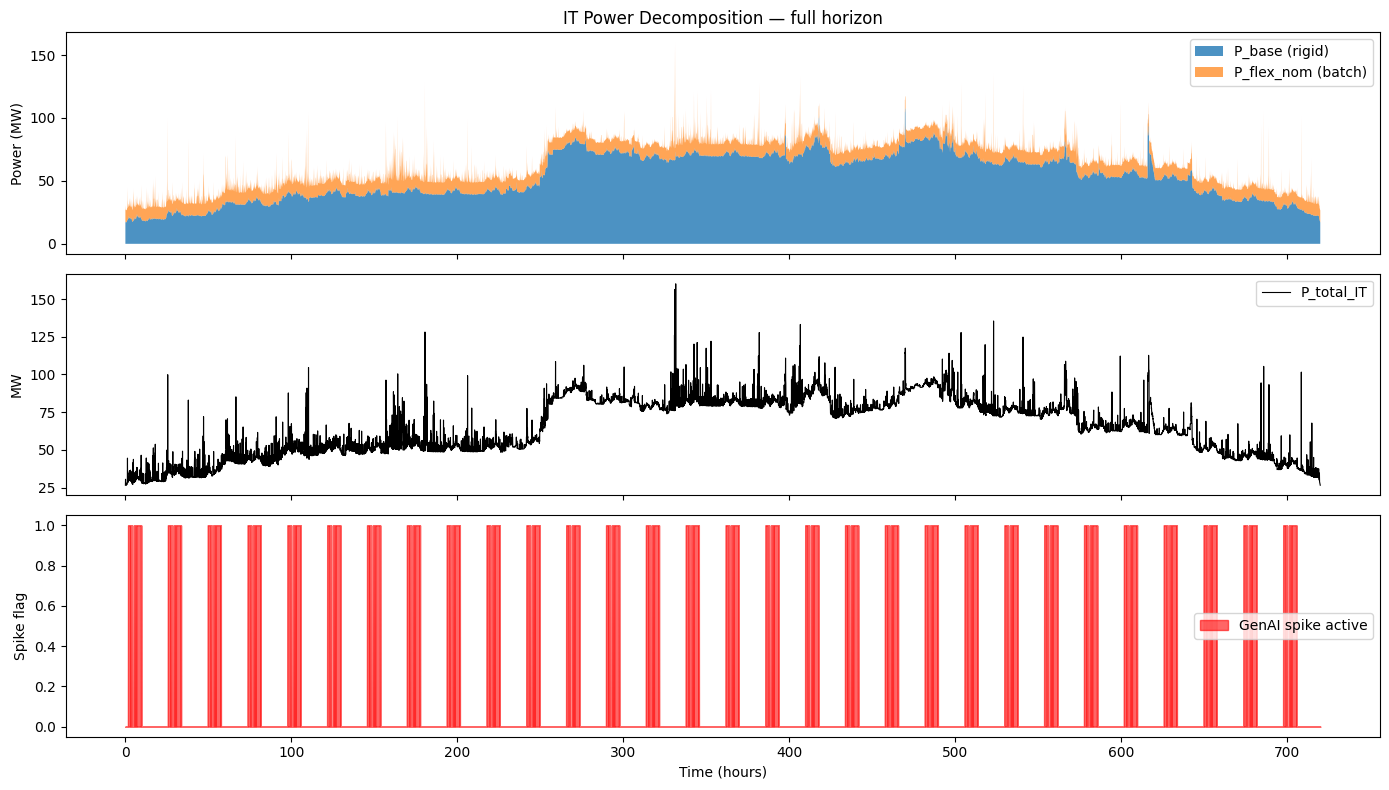

Spike fraction: 25.0%


In [2]:
states = []
wl.reset(seed=42)
for _ in range(wl.horizon_ticks):
    states.append(wl.step(1.0))

t_h  = np.arange(len(states)) * 300 / 3600          # hours
p_b  = np.array([s.p_base_kw  for s in states]) / 1e3
p_fn = np.array([s.p_flex_nom_kw for s in states]) / 1e3
p_to = p_b + p_fn
spk  = np.array([s.is_spike_active for s in states], dtype=float)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].fill_between(t_h, p_b,  alpha=0.8, label="P_base (rigid)")
axes[0].fill_between(t_h, p_to, p_b, alpha=0.7, label="P_flex_nom (batch)")
axes[0].set_ylabel("Power (MW)"); axes[0].legend(loc="upper right"); axes[0].set_title("IT Power Decomposition — full horizon")

axes[1].plot(t_h, p_to, lw=0.8, label="P_total_IT", color="k")
axes[1].set_ylabel("MW"); axes[1].legend()

axes[2].fill_between(t_h, spk, alpha=0.6, color="red", label="GenAI spike active")
axes[2].set_ylabel("Spike flag"); axes[2].set_xlabel("Time (hours)"); axes[2].legend()

plt.tight_layout(); plt.savefig("notebooks/fig_workload_timeseries.png", dpi=120); plt.show()
print(f"Spike fraction: {spk.mean()*100:.1f}%")

## 1.2 Power Distribution Histograms

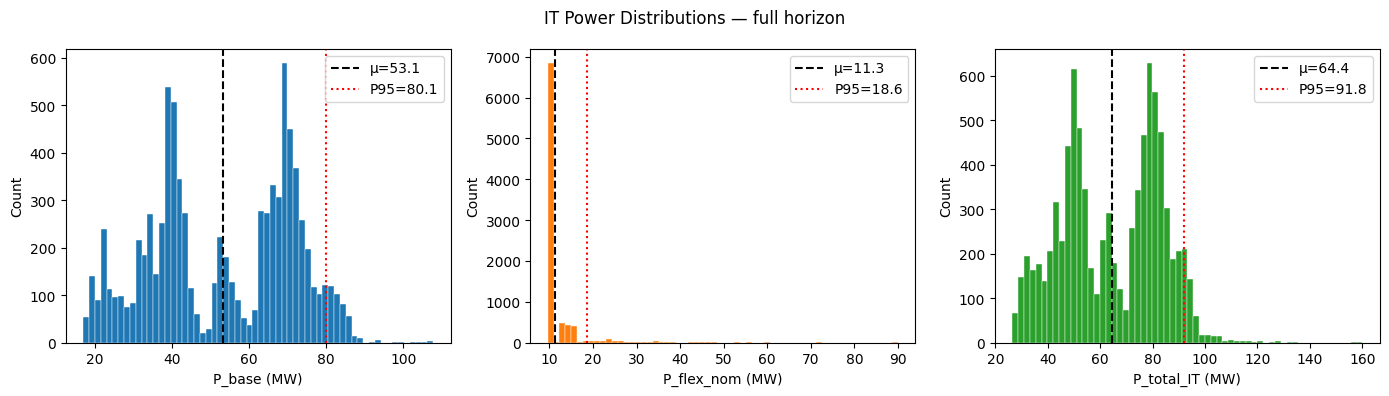

P_base        min=16.9  mean=53.1  max=107.8  std=18.5  MW
P_flex_nom    min=9.6  mean=11.3  max=90.0  std=5.0  MW
P_total_IT    min=26.5  mean=64.4  max=160.1  std=18.8  MW


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, data, label, color in zip(
        axes,
        [p_b, p_fn, p_to],
        ["P_base (MW)", "P_flex_nom (MW)", "P_total_IT (MW)"],
        ["tab:blue", "tab:orange", "tab:green"]):
    ax.hist(data, bins=60, color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(data.mean(), color="k", ls="--", label=f"μ={data.mean():.1f}")
    ax.axvline(np.percentile(data, 95), color="red", ls=":", label=f"P95={np.percentile(data,95):.1f}")
    ax.set_xlabel(label); ax.set_ylabel("Count"); ax.legend()
plt.suptitle("IT Power Distributions — full horizon"); plt.tight_layout()
plt.savefig("notebooks/fig_workload_hist.png", dpi=120); plt.show()

for name, arr in [("P_base", p_b), ("P_flex_nom", p_fn), ("P_total_IT", p_to)]:
    print(f"{name:12s}  min={arr.min():.1f}  mean={arr.mean():.1f}  max={arr.max():.1f}  std={arr.std():.1f}  MW")

## 1.3 DVFS Throttle Effect (Transition Behaviour)

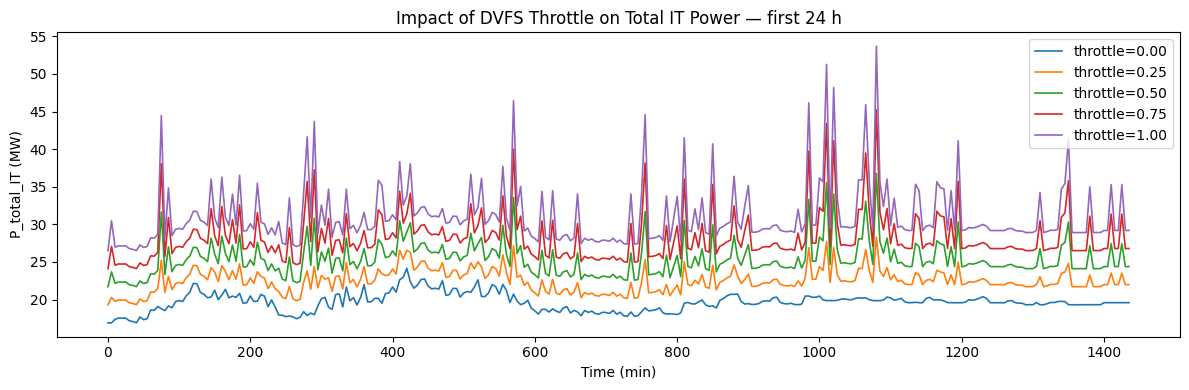

In [4]:
throttles = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, ax = plt.subplots(figsize=(12, 4))
for th in throttles:
    wl.reset(seed=42)
    vals = []
    for _ in range(288):    # 24 h
        s = wl.step(th)
        vals.append((s.p_base_kw + s.p_flex_kw) / 1e3)
    ax.plot(np.arange(288) * 5, vals, lw=1.2, label=f"throttle={th:.2f}")
ax.set_xlabel("Time (min)"); ax.set_ylabel("P_total_IT (MW)")
ax.set_title("Impact of DVFS Throttle on Total IT Power — first 24 h"); ax.legend()
plt.tight_layout(); plt.savefig("notebooks/fig_workload_dvfs.png", dpi=120); plt.show()

## 1.4 Spike Analysis

Total spike events     : 300
Mean spike duration    : 36.0 min
Max  spike duration    : 175.0 min


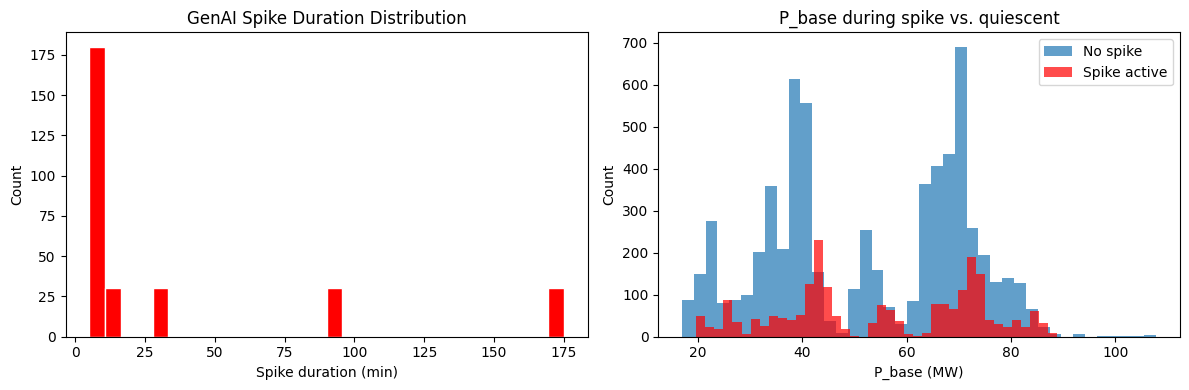

In [5]:
# Lengths of consecutive spike runs
spike_lengths, run = [], 0
for s in states:
    if s.is_spike_active:
        run += 1
    elif run:
        spike_lengths.append(run * 5)   # minutes
        run = 0
if run: spike_lengths.append(run * 5)

print(f"Total spike events     : {len(spike_lengths)}")
print(f"Mean spike duration    : {np.mean(spike_lengths):.1f} min")
print(f"Max  spike duration    : {np.max(spike_lengths):.1f} min")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(spike_lengths, bins=30, color="red", edgecolor="white")
axes[0].set_xlabel("Spike duration (min)"); axes[0].set_ylabel("Count")
axes[0].set_title("GenAI Spike Duration Distribution")

spike_p = np.array([s.p_base_kw for s, sp in zip(states, spk) if sp]) / 1e3
no_sp_p = np.array([s.p_base_kw for s, sp in zip(states, spk) if not sp]) / 1e3
axes[1].hist(no_sp_p, bins=40, alpha=0.7, label="No spike", color="tab:blue")
axes[1].hist(spike_p,  bins=40, alpha=0.7, label="Spike active", color="red")
axes[1].set_xlabel("P_base (MW)"); axes[1].set_ylabel("Count"); axes[1].legend()
axes[1].set_title("P_base during spike vs. quiescent")
plt.tight_layout(); plt.savefig("notebooks/fig_workload_spikes.png", dpi=120); plt.show()